In [1]:
from rank_bm25 import BM25Okapi
import sentence_transformers
import faiss
import sqlite3
import faiss 
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
model = sentence_transformers.SentenceTransformer('all-MiniLM-L6-v2')

d:\Codes\End-to-End Projects\news-intelligence-system-genai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8526.19it/s]


## Simulator Test

In [1]:
from ingestion.simulator import ReadingSessionSimulator
from ingestion.fetcher import NewsFetcher  
import os

In [ ]:

news_api_key = os.getenv('NEWS_API_KEY')
fetcher = NewsFetcher('us', news_api_key)
news_data = fetcher.fetch_news()
fetcher.store_news(news_data)
fetcher.print_recent_news()

In [2]:
sim=ReadingSessionSimulator("session.db")
sim.simulate_human_session()

'0dd6452c3bf64d6298cae9557ef52945'

In [3]:
sim.simulate_bot_session()

'f8d9469eef3b4f82a3decec8c2a56815'

In [ ]:

simulator.simulate_session(type="bot")

## Chunking Test

In [39]:
text = 'Artificial intelligence is changing how people interact with technology every day. From recommendation systems to virtual assistants, machine learning models are becoming increasingly common! Researchers continue to explore new architectures that improve efficiency and accuracy. Meanwhile, penguins in Antarctica spend months adapting to extreme weather conditions.\n\n\n\nThe old lighthouse stood on the edge of the cliff, overlooking the restless sea. Waves crashed against the rocks below, sending sprays of water into the air! Despite decades of storms, the structure remained remarkably resilient. How many sailors had relied on its guiding light over the years?\n\nA small café opened near the train station last month. Customers quickly became fond of its freshly baked pastries and aromatic coffee! Some visitors came to work quietly on their laptops, while others gathered with friends. What makes a place feel welcoming and memorable?\n\n\nDeep within the rainforest, countless species coexist in a delicate balance. Brightly colored birds dart between the trees while insects hum in the background! Environmental scientists monitor these ecosystems to better understand biodiversity. Can conservation efforts keep pace with the challenges posed by climate change?'

In [40]:
# Converting Text Into Paragraphs
import re

paragraphs = re.split(r'\n+', text.strip())
for paragraph in paragraphs:
    print(paragraph)
print("Total Paragraphs:", len(paragraphs))


Artificial intelligence is changing how people interact with technology every day. From recommendation systems to virtual assistants, machine learning models are becoming increasingly common! Researchers continue to explore new architectures that improve efficiency and accuracy. Meanwhile, penguins in Antarctica spend months adapting to extreme weather conditions.
The old lighthouse stood on the edge of the cliff, overlooking the restless sea. Waves crashed against the rocks below, sending sprays of water into the air! Despite decades of storms, the structure remained remarkably resilient. How many sailors had relied on its guiding light over the years?
A small café opened near the train station last month. Customers quickly became fond of its freshly baked pastries and aromatic coffee! Some visitors came to work quietly on their laptops, while others gathered with friends. What makes a place feel welcoming and memorable?
Deep within the rainforest, countless species coexist in a delic

In [41]:
all_sentences = []
for paragraph in paragraphs:
    sentences = re.split(r'(?<=[.!?]) +', paragraph)
    all_sentences.extend(sentences)
    print(sentences)
print("Total Sentences:", len(all_sentences))

['Artificial intelligence is changing how people interact with technology every day.', 'From recommendation systems to virtual assistants, machine learning models are becoming increasingly common!', 'Researchers continue to explore new architectures that improve efficiency and accuracy.', 'Meanwhile, penguins in Antarctica spend months adapting to extreme weather conditions.']
['The old lighthouse stood on the edge of the cliff, overlooking the restless sea.', 'Waves crashed against the rocks below, sending sprays of water into the air!', 'Despite decades of storms, the structure remained remarkably resilient.', 'How many sailors had relied on its guiding light over the years?']
['A small café opened near the train station last month.', 'Customers quickly became fond of its freshly baked pastries and aromatic coffee!', 'Some visitors came to work quietly on their laptops, while others gathered with friends.', 'What makes a place feel welcoming and memorable?']
['Deep within the rainfor

In [42]:
para1 = paragraphs[0]
sentences_para1 = re.split(r'(?<=[.!?]) +', para1)
sentences_para1

['Artificial intelligence is changing how people interact with technology every day.',
 'From recommendation systems to virtual assistants, machine learning models are becoming increasingly common!',
 'Researchers continue to explore new architectures that improve efficiency and accuracy.',
 'Meanwhile, penguins in Antarctica spend months adapting to extreme weather conditions.']

In [43]:
embeddings = model.encode(sentences_para1)
sims = cosine_similarity(embeddings, embeddings)

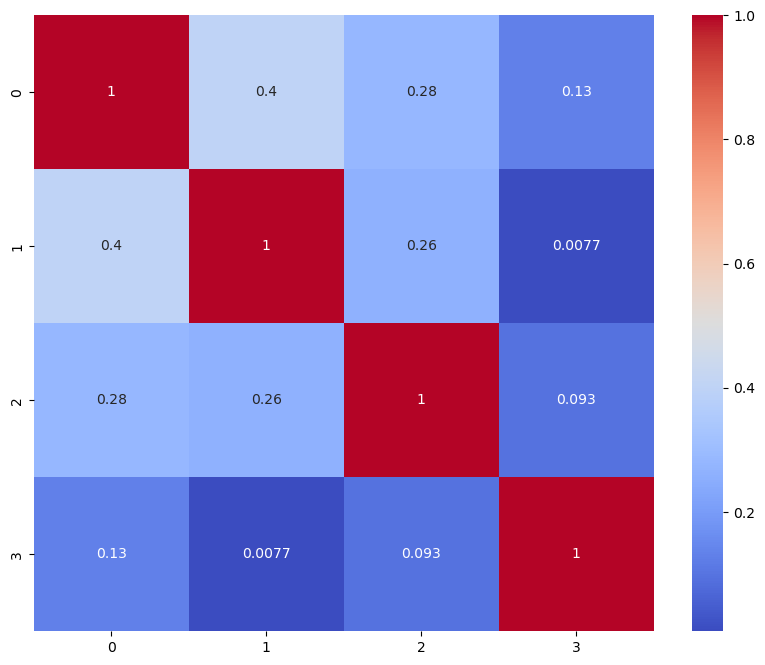

In [44]:
from seaborn import heatmap
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
heatmap(sims, annot=True, cmap='coolwarm')
plt.show()

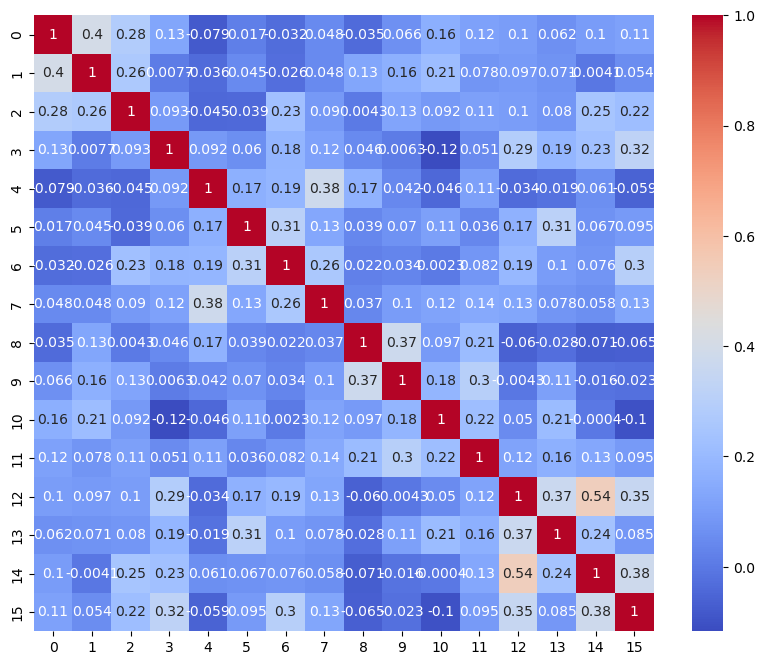

In [59]:
all_embeddings = model.encode(all_sentences)
all_sims = cosine_similarity(all_embeddings, all_embeddings)
plt.figure(figsize=(10, 8))
heatmap(all_sims, annot=True, cmap='coolwarm')
plt.show()

In [61]:
all_sentences[4], all_sentences[5], all_sentences[10], all_sentences[11]

('The old lighthouse stood on the edge of the cliff, overlooking the restless sea.',
 'Waves crashed against the rocks below, sending sprays of water into the air!',
 'Some visitors came to work quietly on their laptops, while others gathered with friends.',
 'What makes a place feel welcoming and memorable?')

In [51]:
cosine_similarity(embeddings[0].reshape(1, -1), embeddings[3].reshape(1, -1))

array([[0.12975156]], dtype=float32)

Conclusion: 0.2 Can be the threshold for Unrelated sentences

In [52]:
chunk_threshold = 500
paragraph = paragraphs[0]
chunks = []
sentences = re.split(r'(?<=[.!?]) +', paragraph)
embeddings = model.encode(sentences)
curr_chunk = ""
for i, sentence in enumerate(sentences):
    sim = cosine_similarity(embeddings[i].reshape(1, -1), embeddings[i-1].reshape(1, -1)) if i > 0 else 1
    if len(curr_chunk) + len(sentence) <= chunk_threshold and sim > 0.2:
        curr_chunk += " " + sentence
    else:
        chunks.append(curr_chunk.strip())
        curr_chunk = sentence

# Append the last chunk if it exists
if curr_chunk:
    chunks.append(curr_chunk.strip())


In [53]:
for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1}: {chunk}\n")

Chunk 1: Artificial intelligence is changing how people interact with technology every day. From recommendation systems to virtual assistants, machine learning models are becoming increasingly common! Researchers continue to explore new architectures that improve efficiency and accuracy.

Chunk 2: Meanwhile, penguins in Antarctica spend months adapting to extreme weather conditions.



In [63]:
def run_for(chunk_threshold, similarity_threshold):
    chunks = []
    for paragraph in paragraphs:
        sentences = re.split(r'(?<=[.!?]) +', paragraph)
        embeddings = model.encode(sentences)
        curr_chunk = ""
        for i, sentence in enumerate(sentences):
            sim = cosine_similarity(embeddings[i].reshape(1, -1), embeddings[i-1].reshape(1, -1)) if i > 0 else 1
            if len(curr_chunk) + len(sentence) <= chunk_threshold and sim > similarity_threshold:
                curr_chunk += " " + sentence
            else:
                chunks.append(curr_chunk.strip())
                curr_chunk = sentence

        # Append the last chunk if it exists
        if curr_chunk:
            chunks.append(curr_chunk.strip())
    return chunks

In [69]:
result1 = run_for(chunk_threshold=500, similarity_threshold=0.35)
result2 = run_for(chunk_threshold=500, similarity_threshold=0.1)


len(result1), len(result2)

(12, 5)

!Important

Any Sentence might be very similar to an other existing sentence in the paragraph that is not adjacent to it, However this pair will not be considered when using this code

In [ ]:
# Reimplement to compare embedding of current sentence with that of entire current chunk instead of just the previous sentence.

chunk_threshold = 1 # EDGE CASE
sim_threshold = 0.2
paragraph = paragraphs[0]
chunks = []
sentences = re.split(r'(?<=[.!?]) +', paragraph)
embeddings = model.encode(sentences)

curr_chunk = sentences[0]
curr_chunk_embedding = embeddings[0]

# Start from the second sentence to avoid adding the first sentence twice
for i in range(1, len(sentences)):
    sentence = sentences[i]
    sim = cosine_similarity(
        embeddings[i].reshape(1, -1),
        curr_chunk_embedding.reshape(1, -1)
    ).item()

    if len(curr_chunk) + len(sentence) <= chunk_threshold and sim > sim_threshold:
        curr_chunk += " " + sentence
        # Update chunk embedding by taking the mean
        curr_chunk_embedding = np.mean([curr_chunk_embedding, embeddings[i]], axis=0)
    else:
        chunks.append(curr_chunk.strip())
        curr_chunk = sentence
        curr_chunk_embedding = embeddings[i]

# Append the last chunk if it exists
if curr_chunk:
    chunks.append(curr_chunk.strip())

In [96]:
#FINAL
def chunk(text, chunk_threshold=500, sim_threshold=0.2):
    paragraphs = re.split(r'\n+', text.strip()) #Splitting the text into paragraphs based on \n or \n\n
    chunks = []
    for paragraph in paragraphs: # Prevents Cross-Paragraph Sentence Merging/Splitting
        sentences = re.split(r'(?<=[.!?]) +', paragraph)
        embeddings = model.encode(sentences) 
        current_chunk = sentences[0]
        curr_chunk_embedding = embeddings[0]
        for i in range(1, len(sentences)):
            sentence = sentences[i]
            # Find Similarity between the current chunk and the next sentence
            sim = cosine_similarity(embeddings[i].reshape(1, -1), curr_chunk_embedding.reshape(1, -1)).item()
            # Merging Chunks based on the threshold and similarity
            if len(current_chunk) + len(sentence) + 1 <= chunk_threshold and sim > sim_threshold:
                current_chunk += " " + sentence
                # Update Chunk Embedding by taking the mean 
                curr_chunk_embedding = np.mean([curr_chunk_embedding, embeddings[i]], axis=0)
            else:
                chunks.append(current_chunk.strip())
                current_chunk = sentence
                curr_chunk_embedding = embeddings[i]
        if current_chunk:
            chunks.append(current_chunk.strip())
    print(f"Produced {len(chunks)} Chunks for {len(paragraphs)} Paragraphs")
    return chunks

In [97]:
chunks = chunk(text)
for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1}: {chunk}\n")

Produced 7 Chunks for 4 Paragraphs
Chunk 1: Artificial intelligence is changing how people interact with technology every day. From recommendation systems to virtual assistants, machine learning models are becoming increasingly common! Researchers continue to explore new architectures that improve efficiency and accuracy.

Chunk 2: Meanwhile, penguins in Antarctica spend months adapting to extreme weather conditions.

Chunk 3: The old lighthouse stood on the edge of the cliff, overlooking the restless sea.

Chunk 4: Waves crashed against the rocks below, sending sprays of water into the air! Despite decades of storms, the structure remained remarkably resilient. How many sailors had relied on its guiding light over the years?

Chunk 5: A small café opened near the train station last month. Customers quickly became fond of its freshly baked pastries and aromatic coffee!

Chunk 6: Some visitors came to work quietly on their laptops, while others gathered with friends. What makes a place 

## FAISS Test

In [2]:
index = faiss.read_index("faiss.index")

In [3]:
print("Total vectors in index:", index.ntotal)
print("Is ID mapping enabled:", isinstance(index, faiss.IndexIDMap))

Total vectors in index: 16
Is ID mapping enabled: True


In [4]:
ids = faiss.vector_to_array(index.id_map)

print("Stored IDs:")
print(ids)

Stored IDs:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


## Fusion Algorithm Test

In [2]:
#Init
from rank_bm25 import BM25Okapi
meta_conn = sqlite3.connect('metadata.db')
bm25_conn = sqlite3.connect('bm25.db')
index = faiss.read_index("faiss.index")

meta_cursor = meta_conn.cursor()
bm25_cursor = bm25_conn.cursor()


#### Embedding Search Scores

In [20]:

query = "Where Do penguins Spend Their Winters?"
query_embedding = model.encode([query]).astype("float32")

In [13]:
D, I = index.search(query_embedding, k=5)
print("Distances:", D)
print("IDs:", I)

Distances: [[0.49395958 1.5256039  1.558389   1.6800966  1.795018  ]]
IDs: [[2 5 6 3 4]]


In [14]:
docs = []

for i in I.squeeze():
    content = meta_cursor.execute(
        '''
        SELECT content
        FROM chunks
        WHERE id = ?
        ''',
        (int(i),)
    ).fetchone()

    if content:
        docs.append(content[0])

print(f'{"Index":^5} | {"Score":^10} | Chunk')
print('--'*50)
for i, d, doc in zip(I.squeeze(), D.squeeze(), docs):
    print(f'{i:^5} | {d:^10.2f} | {doc}')
    

Index |   Score    | Chunk
----------------------------------------------------------------------------------------------------
  2   |    0.49    | Meanwhile, penguins in Antarctica spend months adapting to extreme weather conditions.
  5   |    1.53    | Deep within the rainforest, countless species coexist in a delicate balance. Brightly colored birds dart between the trees while insects hum in the background! Environmental scientists monitor these ecosystems to better understand biodiversity.
  6   |    1.56    | Can conservation efforts keep pace with the challenges posed by climate change?
  3   |    1.68    | The old lighthouse stood on the edge of the cliff, overlooking the restless sea. Waves crashed against the rocks below, sending sprays of water into the air! Despite decades of storms, the structure remained remarkably resilient. How many sailors had relied on its guiding light over the years?
  4   |    1.80    | A small café opened near the train station last month. Custo

#### BM25 Scores

In [21]:
bm25_cursor.execute("""
    SELECT chunk_id, tokens
    FROM bm25_docs
""")

rows = bm25_cursor.fetchall()

In [22]:
chunk_ids = []
tokenized_corpus = []
for chunk_id, tokens in rows:
    chunk_ids.append(chunk_id)
    tokenized_corpus.append(
        tokens.split()
    )
bm25 = BM25Okapi(tokenized_corpus)

In [23]:
from nltk.tokenize import word_tokenize
query_tokens = word_tokenize(query)
query_tokens

['Where', 'Do', 'penguins', 'Spend', 'Their', 'Winters', '?']

In [24]:
scores = bm25.get_scores(query_tokens)
scores

array([0.        , 1.82407968, 0.        , 0.        , 0.        ,
       0.        ])

In [25]:
results = list(
    zip(chunk_ids, scores)
)

results.sort(
    key=lambda x: x[1],
    reverse=True
)

In [27]:
ids = []
docs = []
for result in results:
    value = result[0]
    ids.append(value)


for i in ids:
    content = meta_cursor.execute(
        '''
        SELECT content
        FROM chunks
        WHERE id = ?
        ''',
        (int(i),)
    ).fetchone()

    if content:
        docs.append(content[0])


print(f'{"Index":^5} | {"Score":^10} | Chunk')
print('--'*50)
for result, doc in zip(results, docs):
    value = result[0]
    print(f'{value:^5} | {result[1]:^10.2f} | {doc}')
    

Index |   Score    | Chunk
----------------------------------------------------------------------------------------------------
  2   |    1.82    | Meanwhile, penguins in Antarctica spend months adapting to extreme weather conditions.
  1   |    0.00    | Artificial intelligence is changing how people interact with technology every day. From recommendation systems to virtual assistants, machine learning models are becoming increasingly common! Researchers continue to explore new architectures that improve efficiency and accuracy.
  3   |    0.00    | The old lighthouse stood on the edge of the cliff, overlooking the restless sea. Waves crashed against the rocks below, sending sprays of water into the air! Despite decades of storms, the structure remained remarkably resilient. How many sailors had relied on its guiding light over the years?
  4   |    0.00    | A small café opened near the train station last month. Customers quickly became fond of its freshly baked pastries and aromati



| FAISS | BM25 | 
| -------- | -------- |
| 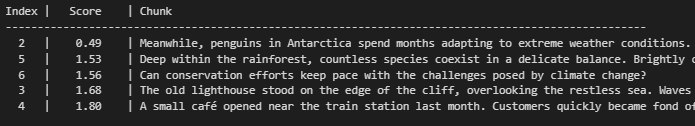  | 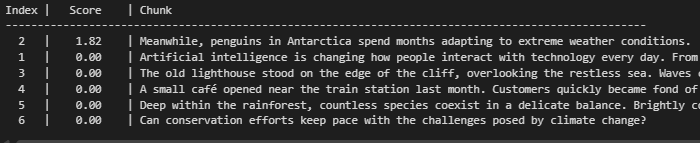| 

#### Fusion Formula

1. Since FAISS Scores are distances (Less the Better), they must be inverted. Considering (S) as Score:

$$S_{f,\text{inv}} = S_{f,\max} - S_f$$

2. Both Scores need to be normalized to the same scale. For simplicity, Min-Max Normalization is used:

$$S_{\text{norm}} = \frac{S - S_{\min}}{S_{\max} - S_{\min} + \epsilon}$$

3. Retriever confidence is estimated using the variance of normalized scores:

$$\sigma_f^2 = \mathrm{Var}(S_{f,\text{norm}}), \qquad \sigma_b^2 = \mathrm{Var}(S_{b,\text{norm}})$$

4. Documents missing in either FAISS or BM25 are assigned the lowest normalized score:

$$S_{\text{missing}} = 0$$

5. An adaptive weight (\alpha) is computed from the score variances:

$$\alpha = \frac{\sigma_f^2}{\sigma_f^2 + \sigma_b^2 + \epsilon}$$
Add a small (\epsilon) to prevent division by zero in cases where: $S_{\max} = S_{\min}$ or $k <= 1$

Finally, for any Document with ID (i) in Top-K Documents, the Fusion Score is:

$$
S^i =
\alpha
\left(
\frac{S_{f,\max}-S_f^i}
{S_{f,\max}-S_{f,\min}+\epsilon}
\right)
+
(1-\alpha)
\left(
\frac{S_b^i-S_{b,\min}}
{S_{b,\max}-S_{b,\min}+\epsilon}
\right)
$$

where

($S^i$) = Final hybrid score for document (i)

($S_f^i$, $S_b^i$) = Raw FAISS and BM25 scores

($\sigma_f^2, \sigma_b^2$) = Variance of normalized FAISS and BM25 scores

($\epsilon$) = Small constant preventing division by zero


In [54]:
k = 5
FAISS_results = np.array(list(zip(I[0], D[0]))[:k])
BM25_results = np.array(results[:k])


In [55]:
BM25_results

array([[2.        , 1.82407968],
       [1.        , 0.        ],
       [3.        , 0.        ],
       [4.        , 0.        ],
       [5.        , 0.        ]])

In [127]:

bm25_min = BM25_results[:,1].min()
bm25_max = BM25_results[:,1].max()
BM25_results[:,1] = (BM25_results[:,1] - bm25_min) / (bm25_max - bm25_min)

In [128]:
BM25_results

array([[2., 1.],
       [1., 0.],
       [3., 0.],
       [4., 0.],
       [5., 0.]])

In [56]:
FAISS_results

array([[2.        , 0.49395958],
       [5.        , 1.52560389],
       [6.        , 1.55838895],
       [3.        , 1.68009663],
       [4.        , 1.79501796]])

In [124]:
FAISS_results[:,1] = FAISS_results[:,1].max() - FAISS_results[:,1]
FAISS_results

array([[2.        , 1.30105838],
       [5.        , 0.26941407],
       [6.        , 0.23662901],
       [3.        , 0.11492133],
       [4.        , 0.        ]])

In [129]:
faiss_min = FAISS_results[:,1].min()
faiss_max = FAISS_results[:,1].max()
FAISS_results[:,1] = (FAISS_results[:,1] - faiss_min) / (faiss_max - faiss_min)
FAISS_results

array([[2.        , 1.        ],
       [5.        , 0.207073  ],
       [6.        , 0.18187424],
       [3.        , 0.08832911],
       [4.        , 0.        ]])

In [134]:
variance_faiss = np.var(FAISS_results[:,1])
variance_bm25 = np.var(BM25_results[:,1])
variance_faiss, variance_bm25

(0.12945808260171163, 0.16000000000000006)

In [136]:
alpha = variance_faiss / (variance_faiss + variance_bm25)
alpha

0.44724293561995043

In [130]:
# Find All Doc IDs (present in both BM25 and FAISS results) via Set Union
all_doc_ids = set(BM25_results[:, 0]).union(set(FAISS_results[:, 0]))
all_doc_ids

{1.0, 2.0, 3.0, 4.0, 5.0, 6.0}

In [141]:

# For each id, find the corresponding score in BM25 and FAISS results. If not present, assign a score of 0.
doc_scores = []
for doc_id in all_doc_ids:
    bm25_score = next((score for id, score in BM25_results if id == doc_id), 0)
    faiss_score = next((score for id, score in FAISS_results if id == doc_id), 0)
    combined_score = alpha * faiss_score + (1 - alpha) * bm25_score
    print(f'{alpha:0.2f} * {faiss_score:0.2f} + (1 - {alpha:0.2f}) * {bm25_score:0.2f} = {combined_score:0.2f}')
    doc_scores.append((doc_id, combined_score, bm25_score, faiss_score))

doc_scores_sorted = sorted(doc_scores, key=lambda x: x[1], reverse=True)

print(f'{"Index":^5} | {"Score_Combined":^15} | {"Score_BM25":^10} | {"Score_FAISS":^10} |')
print('--'*50)
for i, combined_score, bm25_score, faiss_score in doc_scores_sorted:
    print(f'{i:^5} | {combined_score:^15.2f} | {bm25_score:^10.2f} | {faiss_score:^10.2f} |')
    

0.45 * 0.00 + (1 - 0.45) * 0.00 = 0.00
0.45 * 1.00 + (1 - 0.45) * 1.00 = 1.00
0.45 * 0.09 + (1 - 0.45) * 0.00 = 0.04
0.45 * 0.00 + (1 - 0.45) * 0.00 = 0.00
0.45 * 0.21 + (1 - 0.45) * 0.00 = 0.09
0.45 * 0.18 + (1 - 0.45) * 0.00 = 0.08
Index | Score_Combined  | Score_BM25 | Score_FAISS |
----------------------------------------------------------------------------------------------------
 2.0  |      1.00       |    1.00    |    1.00    |
 5.0  |      0.09       |    0.00    |    0.21    |
 6.0  |      0.08       |    0.00    |    0.18    |
 3.0  |      0.04       |    0.00    |    0.09    |
 1.0  |      0.00       |    0.00    |    0.00    |
 4.0  |      0.00       |    0.00    |    0.00    |


In [ ]:
# FINAL 

from typing import List, Tuple


def fusion(BM25_results:np.ndarray, FAISS_results:np.ndarray)->List[Tuple[int, float]]:
    doc_scores = []
    if len(BM25_results) == 0 or len(FAISS_results) == 0:
        raise ValueError("BM25_results and FAISS_results must not be empty.")
    if BM25_results.shape[1] != 2 or FAISS_results.shape[1] != 2:
        raise ValueError("BM25_results and FAISS_results must have two columns: [id, score].")
    if not np.issubdtype(BM25_results[:, 0].dtype, np.integer) or not np.issubdtype(FAISS_results[:, 0].dtype, np.integer):
        raise ValueError("The first column of BM25_results and FAISS_results must contain integer IDs.")
    if not np.issubdtype(BM25_results[:, 1].dtype, np.floating) or not np.issubdtype(FAISS_results[:, 1].dtype, np.floating):
        raise ValueError("The second column of BM25_results and FAISS_results must contain float scores.")
    
    BM25_results[:, 1] = (BM25_results[:, 1] - BM25_results[:, 1].min()) / (BM25_results[:, 1].max() - BM25_results[:, 1].min() + 1e-8)  # Normalizing BM25 scores to [0, 1]
    FAISS_results[:, 1] = (FAISS_results[:, 1].max() - FAISS_results[:, 1]) / (FAISS_results[:, 1].max() - FAISS_results[:, 1].min() + 1e-8)  # Normalizing FAISS scores to [0, 1] and inverting
    
    variance_faiss = np.var(FAISS_results[:, 1])
    variance_bm25 = np.var(BM25_results[:, 1])
    alpha = variance_faiss / (variance_faiss + variance_bm25 + 1e-8)  # Weight for FAISS scores
    
    all_doc_ids = set(BM25_results[:, 0]).union(set(FAISS_results[:, 0]))
    for doc_id in all_doc_ids:
        bm25_score = next((score for id, score in BM25_results if id == doc_id), 0)
        faiss_score = next((score for id, score in FAISS_results if id == doc_id), 0)
        combined_score = alpha * faiss_score + (1 - alpha) * bm25_score
        doc_scores.append((doc_id, combined_score))
        
    doc_scores_sorted = sorted(doc_scores, key=lambda x: x[1], reverse=True)
        
    return doc_scores_sorted

## Retrieval Test

In [5]:
import os

os.getcwd()

'd:\\Codes\\End-to-End Projects\\news-intelligence-system-genai\\rag'

In [6]:
from retrieval import HybridRetriever

index_path="faiss.index"
bm25_path="bm25.db"
metadata_path="metadata.db"
retriever = HybridRetriever(index_path, bm25_path, metadata_path, verbose=True)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12876.70it/s]


In [8]:
results = retriever.retrieve("what is artificial intelligence changing in the world", top_k=5)
results

BM25 Results:
[[1.         6.90587813]
 [2.         0.        ]
 [3.         0.        ]
 [4.         0.        ]
 [5.         0.        ]]
FAISS Results:
[[ 1.          0.44319823]
 [ 2.          1.31633532]
 [ 3.          1.51017261]
 [16.          1.66073537]
 [ 4.          1.67648602]]
Normalized BM25 Results:
[[1. 1.]
 [2. 0.]
 [3. 0.]
 [4. 0.]
 [5. 0.]]
Normalized FAISS Results:
[[ 1.          0.77840088]
 [ 2.          0.34183234]
 [ 3.          0.2449137 ]
 [16.          0.16963232]
 [ 4.          0.16175699]]
Variance FAISS: 0.05240668296744642, Variance BM25: 0.15999999953662666, Alpha: 0.24672802137080252
Doc ID: 1.0, BM25 Score: 0.9999999985519582, FAISS Score: 0.7784008830785751, Combined Score: 0.9453252872536904
Doc ID: 2.0, BM25 Score: 0.0, FAISS Score: 0.34183233976364136, Combined Score: 0.08433961683043513
Doc ID: 3.0, BM25 Score: 0.0, FAISS Score: 0.24491369724273682, Combined Score: 0.06042707192730823
Doc ID: 4.0, BM25 Score: 0.0, FAISS Score: 0.1617569923400879, 

[(1,
  0.9453252872536904,
  'Artificial intelligence is changing how people interact with technology every day.'),
 (2,
  0.08433961683043513,
  'From recommendation systems to virtual assistants, machine learning models are becoming increasingly common!'),
 (3,
  0.06042707192730823,
  'Researchers continue to explore new architectures that improve efficiency and accuracy.'),
 (16,
  0.04185304559733906,
  'Can conservation efforts keep pace with the challenges posed by climate change?'),
 (4,
  0.039909982662961946,
  'Meanwhile, penguins in Antarctica spend months adapting to extreme weather conditions.'),
 (5,
  0.0,
  'The old lighthouse stood on the edge of the cliff, overlooking the restless sea.')]

In [9]:
top_score = results[0][1]
top_score

0.9453252872536904

In [10]:
context = "\n\n".join([f"[{i+1}] {content}" for i, (_, _, content) in enumerate(results)])
context

'[1] Artificial intelligence is changing how people interact with technology every day.\n\n[2] From recommendation systems to virtual assistants, machine learning models are becoming increasingly common!\n\n[3] Researchers continue to explore new architectures that improve efficiency and accuracy.\n\n[4] Can conservation efforts keep pace with the challenges posed by climate change?\n\n[5] Meanwhile, penguins in Antarctica spend months adapting to extreme weather conditions.\n\n[6] The old lighthouse stood on the edge of the cliff, overlooking the restless sea.'

## -